In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
%pip install -q dagshub mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 667.2 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 3.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 41.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [3]:
import dagshub
dagshub.init(repo_owner='mesata', repo_name='IEE-CIS-Fraud-Detection', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a1619ba2-dbc9-4586-be8c-10f042337b03&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=ffa2693f6d07485fc896a78c15638695d3cdcde72e157b3c48658d0adfff6885




Output()

Accessing as mesata

Initialized MLflow to track repo "mesata/IEE-CIS-Fraud-Detection"

Repository mesata/IEE-CIS-Fraud-Detection initialized!

🏃 View run rambunctious-owl-852 at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/d1a6bee8d6f04787958eaaa77f1dabf6
🧪 View experiment at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0


# CLEANING

In [4]:
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
del train_transaction, train_identity

In [5]:
nan_stats = train.isnull().mean()
cols_to_drop = nan_stats[nan_stats > 0.8].index
train = train.drop(columns=cols_to_drop) 
num_cols = train.select_dtypes(include=[np.number]).columns
train[num_cols] = train[num_cols].fillna(train[num_cols].median())
print(f"წაიშალა {len(cols_to_drop)} სვეტი. დარჩა {train.shape[1]} სვეტი.")

წაიშალა 74 სვეტი. დარჩა 360 სვეტი.


# FEATURE ENGINEERING

In [6]:
train['TransactionHour'] = (train['TransactionDT'] // 3600) % 24
from sklearn.preprocessing import LabelEncoder
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))

print(f"Encrypted {len(cat_cols)} categorical columns.")

/tmp/ipykernel_57/2022649153.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionHour'] = (train['TransactionDT'] // 3600) % 24


Encrypted 26 categorical columns.


# FEATURE SELECTION

In [7]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01) 
train_selected = train.copy()
num_features = train.select_dtypes(include=[np.number]).columns
selector.fit(train[num_features])
features_to_keep = num_features[selector.get_support()]
all_features = list(features_to_keep) + list(train.select_dtypes(include=['object']).columns)
train = train[all_features]
print(f"Variance Threshold-ის შემდეგ დარჩა {train.shape[1]} სვეტი.")
corr_matrix = train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
train = train.drop(columns=to_drop)
print(f"მაღალი კორელაციის გამო წაიშალა {len(to_drop)} სვეტი.")
print(f"საბოლოო ჯამში დაგვრჩა {train.shape[1]} ყველაზე ინფორმატიული სვეტი.")

Variance Threshold-ის შემდეგ დარჩა 337 სვეტი.
მაღალი კორელაციის გამო წაიშალა 90 სვეტი.
საბოლოო ჯამში დაგვრჩა 247 ყველაზე ინფორმატიული სვეტი.


In [8]:
X_base = train.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1, errors='ignore')
train_enhanced = train.copy()
train_enhanced['hour_sin'] = np.sin(2 * np.pi * train_enhanced['TransactionHour'] / 24)
train_enhanced['hour_cos'] = np.cos(2 * np.pi * train_enhanced['TransactionHour'] / 24)
hour_mean_amt = train_enhanced.groupby('TransactionHour')['TransactionAmt'].transform('mean')
train_enhanced['Amt_to_Hour_Avg'] = train_enhanced['TransactionAmt'] / hour_mean_amt
X_enhanced = train_enhanced.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1, errors='ignore')
y = train['isFraud']

# TRAINING

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import xgboost as xgb

datasets = {
    "Base Dataset": X_base,
    "Enhanced Time Dataset": X_enhanced
}
results = {}
for name, X_data in datasets.items():
    run_name = f"XGBoost_{name.replace(' ', '_')}"
    with mlflow.start_run(run_name=run_name):
        print(f"\n Testing {name}...")
        X_tr, X_te, y_tr, y_te = train_test_split(X_data, y, test_size=0.2, random_state=42, stratify=y)
        
        model = xgb.XGBClassifier(
            n_estimators=100, 
            max_depth=6, 
            learning_rate=0.1, 
            tree_method='hist', 
            random_state=42
        )
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, preds)
        mlflow.log_param("dataset_type", name)
        mlflow.log_metric("auc_score", auc)
        results[name] = auc
        print(f" {name} AUC: {auc:.4f}")
print("\n--- დასკვნა ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")


 Testing Base Dataset...
 Base Dataset AUC: 0.9194
🏃 View run XGBoost_Base_Dataset at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/2dc497909aec47a88182904778e335ae
🧪 View experiment at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0

 Testing Enhanced Time Dataset...
 Enhanced Time Dataset AUC: 0.9156
🏃 View run XGBoost_Enhanced_Time_Dataset at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/4c038aa12b754aee8885d10aa2e01366
🧪 View experiment at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0

--- დასკვნა ---
Base Dataset: 0.9194
Enhanced Time Dataset: 0.9156


/tmp/ipykernel_57/2611988620.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette="RdPu_r")


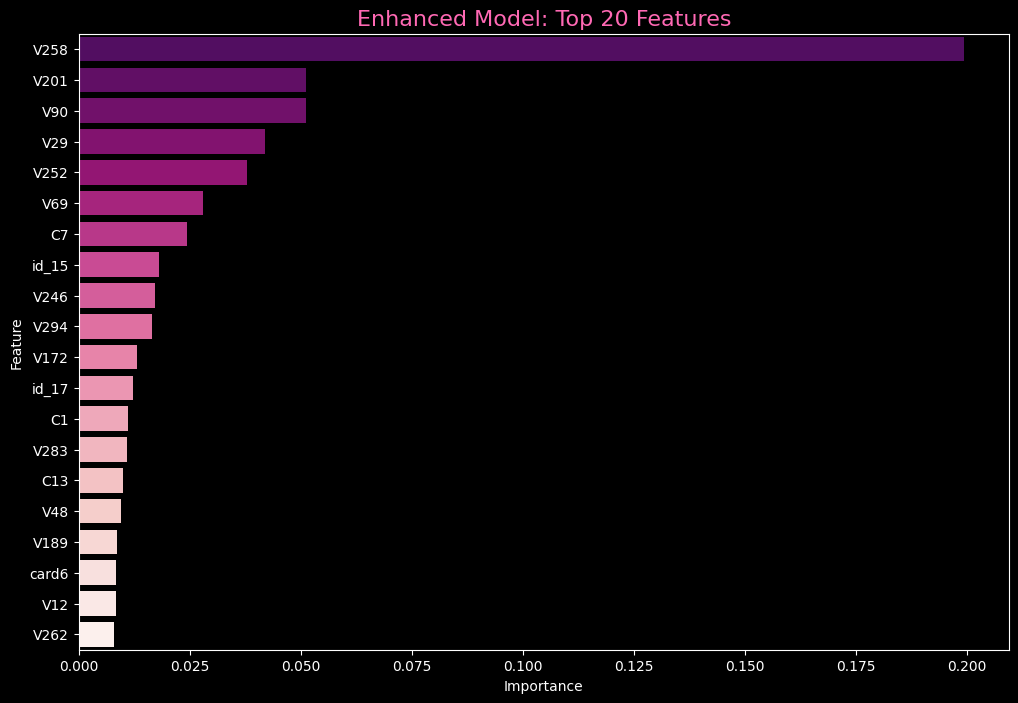

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X_enhanced.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.style.use('dark_background')
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette="RdPu_r")

plt.title('Enhanced Model: Top 20 Features', color="#FF69B4", fontsize=16)
plt.show()